
# Navier–Stokes PINNsFormer：Adam vs ConFIG 多 Seed 验证 Runner

目标：在已经完成 `seed=0` 单次实验的基础上，继续运行 `seed=1, 2`，形成 `seed=0,1,2` 的多随机种子公平对照。

本 notebook 默认：

- **不会重跑 seed=0**；
- 自动检测并复用已有 seed=0 的 Adam / ConFIG checkpoint 与 history；
- 新训练 `seed=1,2`；
- 同一个 seed 内 Adam 与 ConFIG 使用相同的数据抽样 seed、网络初始化 seed、模型、PDE、训练点数、Adam 学习率和 optimizer steps；
- 每个新 seed 保存 `.pt + history.npz + predictions.npz + metrics.csv + run_meta.json`；
- 自动生成：
  - `u/v/p` Relative L2；
  - pressure mean-aligned Relative L2；
  - MAE / Max Absolute Error；
  - final / mean loss；
  - gradient norm / cosine / conflict rate；
  - physics-loss threshold crossing step；
  - wall time / peak allocated VRAM；
  - 每个 seed 的 loss / cosine 曲线；
  - 每个 seed、每个物理量的 Absolute Error 图；
  - 3-seed `mean ± std` 汇总；
  - paired improvement；
  - 多 seed 汇总图。

## 公平比较

比较对象始终是：

```text
PINNsFormer + Adam(lr=1e-4) + simple sum
                 VS
PINNsFormer + Adam(lr=1e-4) + ConFIG
```

ConFIG 训练仍按现有 2-loss 设置：

$$
L_{\mathrm{data}}=L_{u,\mathrm{data}}+L_{v,\mathrm{data}},
$$

$$
L_{\mathrm{physics}}=L_{f_u}+L_{f_v}.
$$

评估统一使用训练一致定义：

$$
u=\frac{\partial\psi}{\partial y},
\qquad
v=-\frac{\partial\psi}{\partial x}.
$$

并在计算所有测试误差前强制将 true / prediction reshape 为 `(N,)`，避免 NumPy broadcasting。

> 默认 `RUN_SEEDS = [1, 2]`。如果某个 seed 已完整运行且 `FORCE_RERUN=False`，会直接复用结果。


In [1]:

from pathlib import Path
import os
import sys
import time
import json
import csv
import gc
import random

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

print("Python executable:", sys.executable)
print("Python version   :", sys.version.split()[0])
print("PyTorch          :", torch.__version__)
print("CUDA runtime     :", torch.version.cuda)
print("CUDA available   :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU              :", torch.cuda.get_device_name(0))


Python executable: /home/simplexity/anaconda3/envs/config_pinn/bin/python
Python version   : 3.10.21
PyTorch          : 2.5.1+cu121
CUDA runtime     : 12.1
CUDA available   : True
GPU              : NVIDIA GeForce GTX 1080 Ti


## 1. 路径与实验配置

In [19]:

# ===== 路径 =====
PINNSFORMER_ROOT = Path(
    os.environ.get("PINNSFORMER_ROOT", "/home/simplexity/cyt/pinnsformer-main")
)

EXPERIMENT_ROOT = Path(
    os.environ.get(
        "PINNSFORMER_CONFIG_ROOT",
        str(PINNSFORMER_ROOT / "pinnsformer-config"),
    )
)

CONFIG_ROOT = Path(
    os.environ.get("CONFIG_ROOT", "/home/simplexity/cyt/ConFIG-main")
)

DATA_PATH = (
    PINNSFORMER_ROOT
    / "demo"
    / "navier_stokes"
    / "cylinder_nektar_wake.mat"
)

MULTISEED_ROOT = EXPERIMENT_ROOT / "outputs" / "navier_stokes_multiseed"
MULTISEED_ROOT.mkdir(parents=True, exist_ok=True)

# ===== 新增 seed =====
# seed=0 已经完成，所以默认只跑 1, 2。
RUN_SEEDS = [1, 2]

# 已完整存在的 seed 默认跳过，避免误重跑。
FORCE_RERUN = False

# ===== 与单 seed 实验完全保持一致 =====
DEVICE = "cuda:0"
N_TRAIN = 800
NUM_STEP = 5
TIME_STEP = 1e-2
EPOCHS = 1000
LR = 1e-4
DIAG_INTERVAL = 10
SNAPSHOT = 100

# Absolute Error 图沿用原 Navier–Stokes demo 的空间 reshape。
GRID_SHAPE = (50, 100)
EXTENT = [-3, 8, -2, 2]

# 用于比较 physics 收敛速度，不是训练超参数。
PHYSICS_THRESHOLDS = [1e-2, 5e-3, 2e-3, 1e-3, 5e-4]

print("PINNSFORMER_ROOT:", PINNSFORMER_ROOT)
print("EXPERIMENT_ROOT :", EXPERIMENT_ROOT)
print("CONFIG_ROOT     :", CONFIG_ROOT)
print("DATA_PATH       :", DATA_PATH)
print("MULTISEED_ROOT  :", MULTISEED_ROOT)
print("RUN_SEEDS       :", RUN_SEEDS)
print("FORCE_RERUN     :", FORCE_RERUN)


PINNSFORMER_ROOT: /home/simplexity/cyt/pinnsformer-main
EXPERIMENT_ROOT : /home/simplexity/cyt/pinnsformer-main/pinnsformer-config
CONFIG_ROOT     : /home/simplexity/cyt/ConFIG-main
DATA_PATH       : /home/simplexity/cyt/pinnsformer-main/demo/navier_stokes/cylinder_nektar_wake.mat
MULTISEED_ROOT  : /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_multiseed
RUN_SEEDS       : [1, 2]
FORCE_RERUN     : False


## 2. 导入当前已有的 PINNsFormer / ConFIG 公共实现

In [3]:

assert DATA_PATH.exists(), f"Missing data: {DATA_PATH}"
assert CONFIG_ROOT.exists(), f"Missing ConFIG repo: {CONFIG_ROOT}"

# navier_stokes_common.py / gradient_diagnostics.py 应位于 pinnsformer-config
assert (EXPERIMENT_ROOT / "navier_stokes_common.py").exists(), (
    f"Missing: {EXPERIMENT_ROOT / 'navier_stokes_common.py'}"
)
assert (EXPERIMENT_ROOT / "gradient_diagnostics.py").exists(), (
    f"Missing: {EXPERIMENT_ROOT / 'gradient_diagnostics.py'}"
)

sys.path.insert(0, str(EXPERIMENT_ROOT))
sys.path.insert(0, str(CONFIG_ROOT))

from conflictfree.grad_operator import ConFIGOperator
from conflictfree.utils import apply_gradient_vector_para_based

from gradient_diagnostics import gradient_vector, ConflictTracker
from navier_stokes_common import (
    PINNsformer,
    init_weights,
    get_n_params,
    load_training_data,
    compute_ns_losses,
    evaluation_tensors,
)

import conflictfree

print("conflictfree:", conflictfree.__file__)


conflictfree: /home/simplexity/cyt/ConFIG-main/conflictfree/__init__.py


## 3. 通用工具：seed、保存、表格、指标

In [4]:

def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def save_history(history, path):
    path = Path(path)
    keys = list(history[0].keys())
    np.savez(
        path,
        **{
            k: np.asarray([row[k] for row in history])
            for k in keys
        },
    )


def load_history(path):
    path = Path(path)
    obj = np.load(path, allow_pickle=True)
    if isinstance(obj, np.lib.npyio.NpzFile):
        out = {k: np.asarray(obj[k]) for k in obj.files}
        obj.close()
        return out
    if isinstance(obj, np.ndarray) and obj.shape == ():
        maybe = obj.item()
        if isinstance(maybe, dict):
            return {k: np.asarray(v) for k, v in maybe.items()}
    raise ValueError(f"Unsupported history file: {path}")


def write_dict_rows_csv(path, rows, fieldnames=None):
    path = Path(path)
    rows = list(rows)
    if not rows:
        return
    if fieldnames is None:
        fieldnames = list(rows[0].keys())
    with path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def read_dict_rows_csv(path):
    with Path(path).open("r", newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


def print_table(rows, columns=None, float_digits=6):
    rows = list(rows)
    if not rows:
        print("(empty)")
        return

    if columns is None:
        columns = list(rows[0].keys())

    def fmt(v):
        if isinstance(v, (float, np.floating)):
            if np.isnan(v):
                return "nan"
            return f"{float(v):.{float_digits}g}"
        return str(v)

    formatted = [
        {c: fmt(row.get(c, "")) for c in columns}
        for row in rows
    ]

    widths = {
        c: max(len(c), max(len(row[c]) for row in formatted))
        for c in columns
    }

    header = " | ".join(c.ljust(widths[c]) for c in columns)
    sep = "-+-".join("-" * widths[c] for c in columns)
    print(header)
    print(sep)
    for row in formatted:
        print(" | ".join(row[c].ljust(widths[c]) for c in columns))


def relative_l2(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    assert y_true.shape == y_pred.shape, (y_true.shape, y_pred.shape)
    denom = np.linalg.norm(y_true, 2)
    return float(np.linalg.norm(y_true - y_pred, 2) / denom)


def mae(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return float(np.mean(np.abs(y_true - y_pred)))


def max_abs_error(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return float(np.max(np.abs(y_true - y_pred)))


def align_pressure_mean(p_true, p_pred):
    p_true = np.asarray(p_true).reshape(-1)
    p_pred = np.asarray(p_pred).reshape(-1)
    return p_pred - np.mean(p_pred) + np.mean(p_true)


def first_step_below(history, key, threshold):
    values = np.asarray(history[key], dtype=float)
    steps = np.asarray(history["step"], dtype=int)
    idx = np.where(values < threshold)[0]
    return int(steps[idx[0]]) if len(idx) else np.nan


def safe_mean(x):
    return float(np.nanmean(np.asarray(x, dtype=float)))


def safe_std(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) <= 1:
        return float("nan")
    return float(np.std(x, ddof=1))


## 4. 模型评估：正确的 u/v/p、pressure gauge 与 Absolute Error

In [5]:

def make_model(device):
    model = PINNsformer(
        d_out=2,
        d_hidden=512,
        d_model=32,
        N=1,
        heads=2,
    ).to(device)
    model.apply(init_weights)
    return model


def evaluation_truth(reference, device):
    ev, truth_raw = evaluation_tensors(
        reference,
        device,
        snap=SNAPSHOT,
        num_step=NUM_STEP,
        time_step=TIME_STEP,
    )
    truth = {
        name: np.asarray(value).reshape(-1)
        for name, value in truth_raw.items()
    }
    return ev, truth


def predict_fields(model, ev):
    # u/v 需要对 psi 求导，因此不能使用 torch.no_grad()
    psi_p = model(ev["x"], ev["y"], ev["t"])
    psi = psi_p[:, :, 0:1]
    p_pred = psi_p[:, :, 1:2]

    u_pred = torch.autograd.grad(
        psi,
        ev["y"],
        grad_outputs=torch.ones_like(psi),
        retain_graph=True,
        create_graph=False,
    )[0]

    v_pred = -torch.autograd.grad(
        psi,
        ev["x"],
        grad_outputs=torch.ones_like(psi),
        retain_graph=False,
        create_graph=False,
    )[0]

    return {
        "u": u_pred.detach().cpu().numpy()[:, 0].reshape(-1),
        "v": v_pred.detach().cpu().numpy()[:, 0].reshape(-1),
        "p": p_pred.detach().cpu().numpy()[:, 0].reshape(-1),
    }


def field_metrics(seed, method, truth, pred):
    rows = []
    for field in ["u", "v", "p"]:
        row = {
            "seed": int(seed),
            "method": method,
            "field": field,
            "relative_l2": relative_l2(truth[field], pred[field]),
            "mae": mae(truth[field], pred[field]),
            "max_absolute_error": max_abs_error(truth[field], pred[field]),
            "mean_aligned_relative_l2": "",
        }
        if field == "p":
            aligned = align_pressure_mean(truth["p"], pred["p"])
            row["mean_aligned_relative_l2"] = relative_l2(
                truth["p"],
                aligned,
            )
        rows.append(row)
    return rows


def save_predictions(path, truth, pred):
    p_aligned = align_pressure_mean(truth["p"], pred["p"])
    np.savez(
        path,
        truth_u=truth["u"],
        truth_v=truth["v"],
        truth_p=truth["p"],
        pred_u=pred["u"],
        pred_v=pred["v"],
        pred_p=pred["p"],
        pred_p_mean_aligned=p_aligned,
    )


def plot_absolute_errors(seed, truth, preds_by_method, output_dir):
    output_dir = ensure_dir(output_dir)

    n_points = len(truth["u"])
    if np.prod(GRID_SHAPE) != n_points:
        raise ValueError(
            f"GRID_SHAPE={GRID_SHAPE} => {np.prod(GRID_SHAPE)} points, "
            f"but evaluation has {n_points}."
        )

    # 同一个 seed、同一个物理量，Adam / ConFIG 共用 vmax，颜色可以公平比较。
    for field in ["u", "v", "p"]:
        errors = {
            method: np.abs(truth[field] - pred[field])
            for method, pred in preds_by_method.items()
        }
        vmax = max(float(np.max(e)) for e in errors.values())

        for method, error in errors.items():
            plt.figure(figsize=(5.5, 3.8))
            im = plt.imshow(
                error.reshape(GRID_SHAPE),
                extent=EXTENT,
                aspect="auto",
                vmin=0.0,
                vmax=vmax,
            )
            plt.xlabel("x")
            plt.ylabel("y")
            plt.title(f"seed={seed} | {method} | {field} Absolute Error")
            plt.colorbar(im, label="Absolute Error")
            plt.tight_layout()

            safe_method = (
                method.lower()
                .replace(" ", "_")
                .replace("+", "plus")
                .replace("-", "_")
            )
            path = output_dir / f"seed_{seed}_{safe_method}_{field}_absolute_error.png"
            plt.savefig(path, dpi=220, bbox_inches="tight")
            plt.show()

    # pressure mean-aligned absolute error
    aligned_errors = {}
    for method, pred in preds_by_method.items():
        aligned_p = align_pressure_mean(truth["p"], pred["p"])
        aligned_errors[method] = np.abs(truth["p"] - aligned_p)

    vmax = max(float(np.max(e)) for e in aligned_errors.values())
    for method, error in aligned_errors.items():
        plt.figure(figsize=(5.5, 3.8))
        im = plt.imshow(
            error.reshape(GRID_SHAPE),
            extent=EXTENT,
            aspect="auto",
            vmin=0.0,
            vmax=vmax,
        )
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title(f"seed={seed} | {method} | mean-aligned p Absolute Error")
        plt.colorbar(im, label="Absolute Error")
        plt.tight_layout()

        safe_method = (
            method.lower()
            .replace(" ", "_")
            .replace("+", "plus")
            .replace("-", "_")
        )
        path = output_dir / f"seed_{seed}_{safe_method}_p_mean_aligned_absolute_error.png"
        plt.savefig(path, dpi=220, bbox_inches="tight")
        plt.show()


## 5. 单次训练函数：Adam Simple-Sum

In [6]:

def train_adam_simple_sum(seed, batch, reference, device, output_dir):
    output_dir = ensure_dir(output_dir)

    set_seed(seed)
    model = make_model(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    print(f"\n[Adam Simple-Sum] seed={seed}")
    print("params:", get_n_params(model))

    history = []
    tracker = ConflictTracker("data", "physics")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.synchronize(device)

    start = time.time()

    for step in tqdm(range(EPOCHS), desc=f"Adam seed={seed}"):
        losses = compute_ns_losses(
            model,
            batch["x"],
            batch["y"],
            batch["t"],
            batch["u"],
            batch["v"],
        )

        cosine = float("nan")
        g_data_norm = float("nan")
        g_physics_norm = float("nan")

        # 与 seed=0 baseline 一致：只在采样 step 额外做 loss-specific gradient diagnostics。
        if step % DIAG_INTERVAL == 0 or step == EPOCHS - 1:
            g_data = gradient_vector(
                losses["data"],
                model,
                retain_graph=True,
            )
            g_physics = gradient_vector(
                losses["physics"],
                model,
                retain_graph=True,
            )
            cosine = tracker.update(
                {"data": g_data, "physics": g_physics}
            )
            g_data_norm = float(g_data.norm())
            g_physics_norm = float(g_physics.norm())

        optimizer.zero_grad(set_to_none=True)
        losses["total"].backward()
        optimizer.step()

        if step % DIAG_INTERVAL == 0 or step == EPOCHS - 1:
            history.append(
                {
                    "step": step,
                    "total": float(losses["total"].detach()),
                    "data": float(losses["data"].detach()),
                    "physics": float(losses["physics"].detach()),
                    "g_data_norm": g_data_norm,
                    "g_physics_norm": g_physics_norm,
                    "cosine": cosine,
                    "conflict": int(np.isfinite(cosine) and cosine < 0),
                }
            )

    if torch.cuda.is_available():
        torch.cuda.synchronize(device)

    elapsed = time.time() - start
    peak_mib = (
        torch.cuda.max_memory_allocated(device) / 1024**2
        if torch.cuda.is_available()
        else float("nan")
    )

    model_path = output_dir / "model.pt"
    history_path = output_dir / "history.npz"
    meta_path = output_dir / "run_meta.json"

    torch.save(model.state_dict(), model_path)
    save_history(history, history_path)

    meta = {
        "seed": int(seed),
        "method": "Adam Simple-Sum",
        "optimizer": "Adam",
        "lr": LR,
        "epochs": EPOCHS,
        "n_train": N_TRAIN,
        "num_step": NUM_STEP,
        "time_step": TIME_STEP,
        "diag_interval": DIAG_INTERVAL,
        "model_params": int(get_n_params(model)),
        "wall_time_s": float(elapsed),
        "peak_vram_mib": float(peak_mib),
        "diagnostic_summary": tracker.summary(),
    }

    with meta_path.open("w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)

    print(f"wall time: {elapsed:.2f}s ({elapsed/60:.2f}min)")
    print(f"peak allocated: {peak_mib:.2f} MiB")
    print("sampled diagnostic conflict:", tracker.summary())

    return model, history, meta


## 6. 单次训练函数：Adam + ConFIG

In [7]:

def train_adam_config(seed, batch, reference, device, output_dir):
    output_dir = ensure_dir(output_dir)

    set_seed(seed)
    model = make_model(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    config_operator = ConFIGOperator()

    print(f"\n[Adam + ConFIG] seed={seed}")
    print("params:", get_n_params(model))

    history = []
    full_tracker = ConflictTracker("data", "physics")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.synchronize(device)

    start = time.time()

    for step in tqdm(range(EPOCHS), desc=f"ConFIG seed={seed}"):
        losses = compute_ns_losses(
            model,
            batch["x"],
            batch["y"],
            batch["t"],
            batch["u"],
            batch["v"],
        )

        g_data = gradient_vector(
            losses["data"],
            model,
            retain_graph=True,
        )
        g_physics = gradient_vector(
            losses["physics"],
            model,
            retain_graph=False,
        )

        cosine = full_tracker.update(
            {"data": g_data, "physics": g_physics}
        )

        g_config = config_operator.calculate_gradient(
            torch.stack([g_data, g_physics]),
            losses=[
                losses["data"].detach(),
                losses["physics"].detach(),
            ],
        )

        optimizer.zero_grad(set_to_none=True)
        apply_gradient_vector_para_based(model, g_config)
        optimizer.step()

        # history 仍只保存与 baseline 相同的采样 step，便于公平统计。
        if step % DIAG_INTERVAL == 0 or step == EPOCHS - 1:
            history.append(
                {
                    "step": step,
                    "total": float(losses["total"].detach()),
                    "data": float(losses["data"].detach()),
                    "physics": float(losses["physics"].detach()),
                    "g_data_norm": float(g_data.norm()),
                    "g_physics_norm": float(g_physics.norm()),
                    "cosine": cosine,
                    "conflict": int(np.isfinite(cosine) and cosine < 0),
                }
            )

    if torch.cuda.is_available():
        torch.cuda.synchronize(device)

    elapsed = time.time() - start
    peak_mib = (
        torch.cuda.max_memory_allocated(device) / 1024**2
        if torch.cuda.is_available()
        else float("nan")
    )

    model_path = output_dir / "model.pt"
    history_path = output_dir / "history.npz"
    meta_path = output_dir / "run_meta.json"

    torch.save(model.state_dict(), model_path)
    save_history(history, history_path)

    meta = {
        "seed": int(seed),
        "method": "Adam + ConFIG",
        "optimizer": "Adam",
        "lr": LR,
        "epochs": EPOCHS,
        "n_train": N_TRAIN,
        "num_step": NUM_STEP,
        "time_step": TIME_STEP,
        "diag_interval": DIAG_INTERVAL,
        "model_params": int(get_n_params(model)),
        "wall_time_s": float(elapsed),
        "peak_vram_mib": float(peak_mib),
        "full_conflict_summary": full_tracker.summary(),
    }

    with meta_path.open("w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)

    print(f"wall time: {elapsed:.2f}s ({elapsed/60:.2f}min)")
    print(f"peak allocated: {peak_mib:.2f} MiB")
    print("full conflict:", full_tracker.summary())

    return model, history, meta


## 7. 每个 seed 的 history 统计与训练曲线

In [8]:

def summarize_history(seed, method, h, run_meta):
    steps = np.asarray(h["step"], dtype=int)
    late = steps >= 700

    return {
        "seed": int(seed),
        "method": method,
        "final_total_loss": float(h["total"][-1]),
        "final_data_loss": float(h["data"][-1]),
        "final_physics_loss": float(h["physics"][-1]),
        "min_total_loss": float(np.min(h["total"])),
        "min_data_loss": float(np.min(h["data"])),
        "min_physics_loss": float(np.min(h["physics"])),
        "mean_total_loss": float(np.mean(h["total"])),
        "mean_data_loss": float(np.mean(h["data"])),
        "mean_physics_loss": float(np.mean(h["physics"])),
        "final_g_data_norm": float(h["g_data_norm"][-1]),
        "final_g_physics_norm": float(h["g_physics_norm"][-1]),
        "mean_cosine": safe_mean(h["cosine"]),
        "sampled_conflict_rate": safe_mean(h["conflict"]),
        "late_mean_cosine": safe_mean(h["cosine"][late]),
        "late_conflict_rate": safe_mean(h["conflict"][late]),
        "wall_time_s": float(run_meta["wall_time_s"]),
        "wall_time_min": float(run_meta["wall_time_s"]) / 60.0,
        "peak_vram_mib": float(run_meta["peak_vram_mib"]),
    }


def threshold_rows(seed, method, h):
    rows = []
    for threshold in PHYSICS_THRESHOLDS:
        rows.append(
            {
                "seed": int(seed),
                "method": method,
                "threshold": float(threshold),
                "first_sampled_step_below": first_step_below(
                    h,
                    "physics",
                    threshold,
                ),
            }
        )
    return rows


def plot_seed_training_curves(seed, adam_h, config_h, output_dir):
    output_dir = ensure_dir(output_dir)

    # 每张图一个独立 figure。
    for key, ylabel, filename in [
        ("total", "Total Loss", "total_loss"),
        ("data", "Data Loss", "data_loss"),
        ("physics", "Physics Loss", "physics_loss"),
    ]:
        plt.figure(figsize=(7, 4))
        plt.semilogy(adam_h["step"], adam_h[key], label="Adam Simple-Sum")
        plt.semilogy(config_h["step"], config_h[key], label="Adam + ConFIG")
        plt.xlabel("Step")
        plt.ylabel(ylabel)
        plt.title(f"seed={seed} | {ylabel}")
        plt.legend()
        plt.tight_layout()
        plt.savefig(
            output_dir / f"seed_{seed}_{filename}_comparison.png",
            dpi=220,
            bbox_inches="tight",
        )
        plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(
        adam_h["step"],
        adam_h["cosine"],
        label="Adam Simple-Sum",
    )
    plt.plot(
        config_h["step"],
        config_h["cosine"],
        label="Adam + ConFIG",
    )
    plt.axhline(0, linestyle="--")
    plt.xlabel("Step")
    plt.ylabel("cos(g_data, g_physics)")
    plt.title(f"seed={seed} | Gradient Cosine")
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        output_dir / f"seed_{seed}_gradient_cosine_comparison.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.semilogy(
        adam_h["step"],
        adam_h["g_data_norm"],
        label="Adam Simple-Sum",
    )
    plt.semilogy(
        config_h["step"],
        config_h["g_data_norm"],
        label="Adam + ConFIG",
    )
    plt.xlabel("Step")
    plt.ylabel("||g_data||")
    plt.title(f"seed={seed} | Data Gradient Norm")
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        output_dir / f"seed_{seed}_g_data_norm_comparison.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.semilogy(
        adam_h["step"],
        adam_h["g_physics_norm"],
        label="Adam Simple-Sum",
    )
    plt.semilogy(
        config_h["step"],
        config_h["g_physics_norm"],
        label="Adam + ConFIG",
    )
    plt.xlabel("Step")
    plt.ylabel("||g_physics||")
    plt.title(f"seed={seed} | Physics Gradient Norm")
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        output_dir / f"seed_{seed}_g_physics_norm_comparison.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()


## 8. 运行 seed=1,2：每个 seed 成对训练并立即评估


SEED 1
batch x shape: (800, 5, 1)

[Adam Simple-Sum] seed=1
params: 454106


Adam seed=1: 100%|██████████| 1000/1000 [10:55<00:00,  1.53it/s]


wall time: 655.59s (10.93min)
peak allocated: 8535.08 MiB
sampled diagnostic conflict: {'n': 101, 'mean_cosine': -0.7019678880598875, 'min_cosine': -0.9919324517250061, 'max_cosine': 0.8560819625854492, 'conflict_rate': 0.8514851485148515}

[Adam + ConFIG] seed=1
params: 454106


ConFIG seed=1: 100%|██████████| 1000/1000 [11:02<00:00,  1.51it/s]


wall time: 662.70s (11.04min)
peak allocated: 7657.07 MiB
full conflict: {'n': 1000, 'mean_cosine': -0.49479861382121454, 'min_cosine': -0.9911906719207764, 'max_cosine': 0.8903890252113342, 'conflict_rate': 0.768}

Field metrics:
seed | method          | field | relative_l2 | mae       | max_absolute_error | mean_aligned_relative_l2
-----+-----------------+-------+-------------+-----------+--------------------+-------------------------
1    | Adam Simple-Sum | u     | 0.0389652   | 0.0256692 | 0.223235           |                         
1    | Adam Simple-Sum | v     | 0.135439    | 0.0283403 | 0.128455           |                         
1    | Adam Simple-Sum | p     | 0.75537     | 0.0942726 | 0.255774           | 0.270944                
1    | Adam + ConFIG   | u     | 0.035889    | 0.0226403 | 0.185718           |                         
1    | Adam + ConFIG   | v     | 0.125598    | 0.0257768 | 0.163878           |                         
1    | Adam + ConFIG   | p     | 1

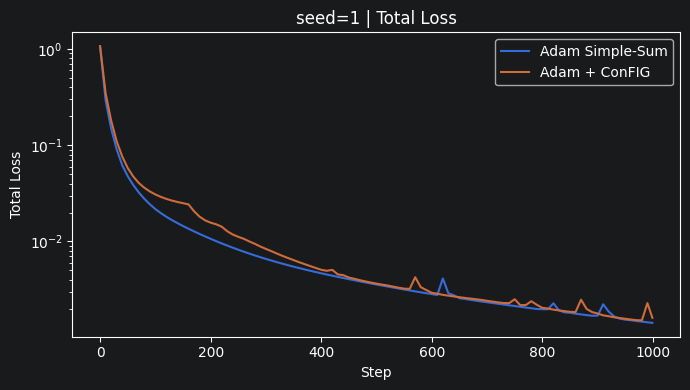

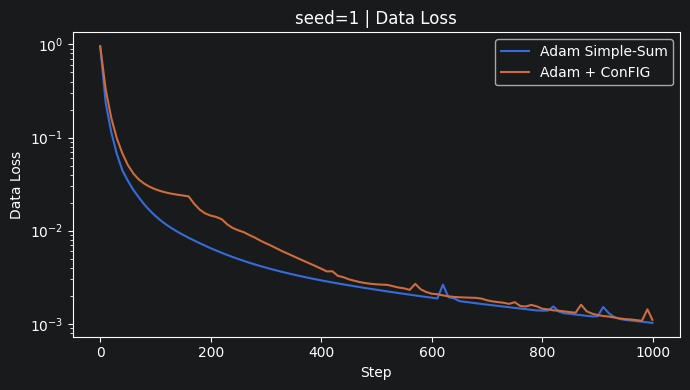

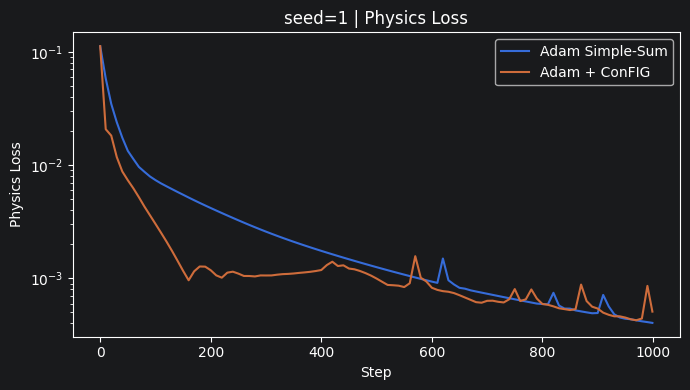

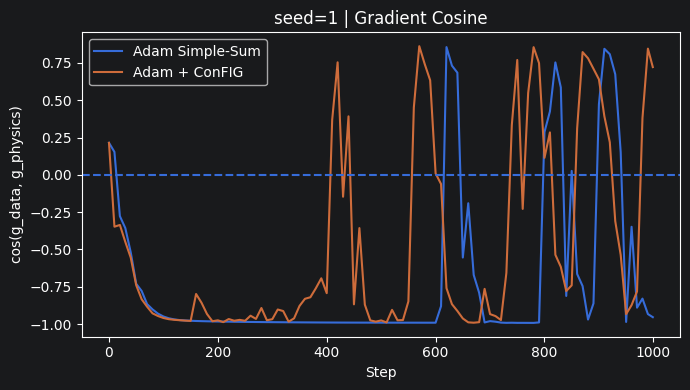

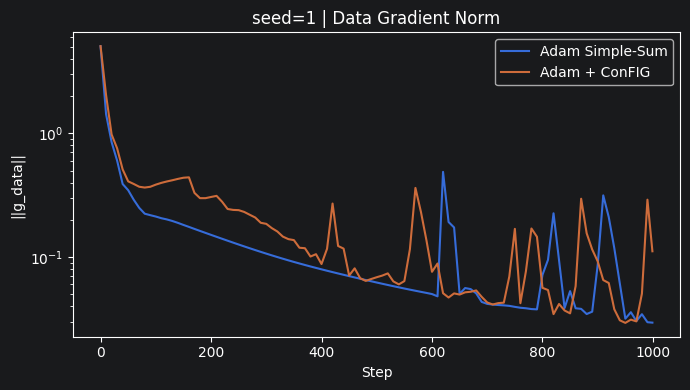

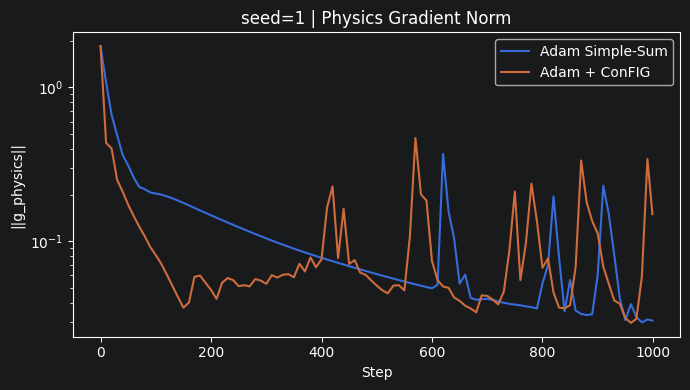

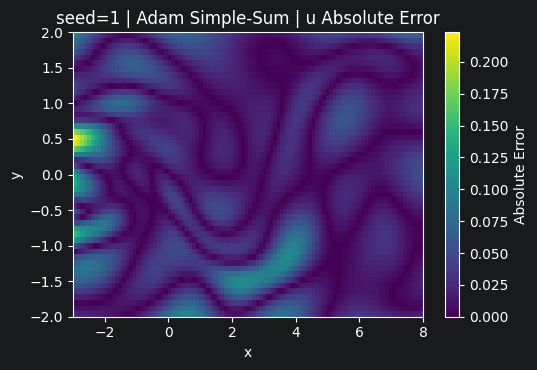

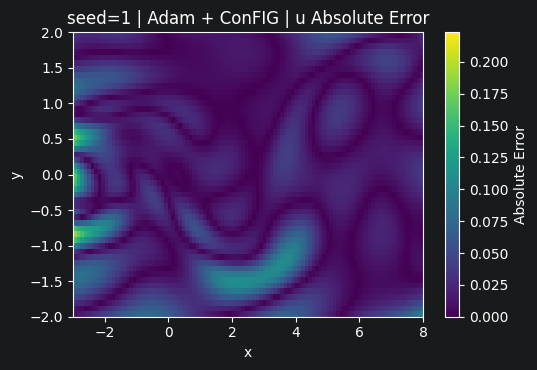

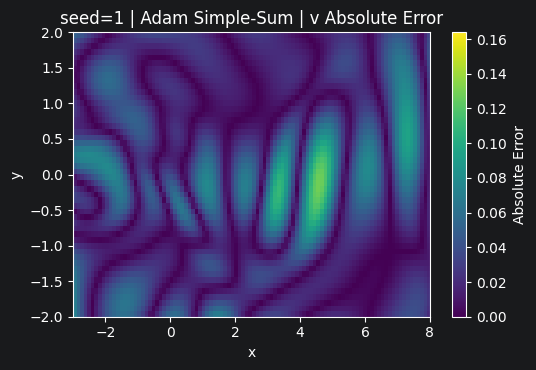

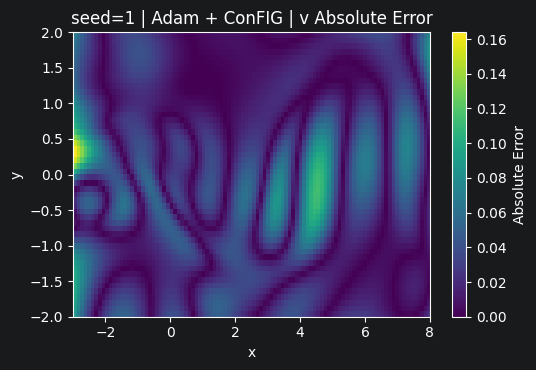

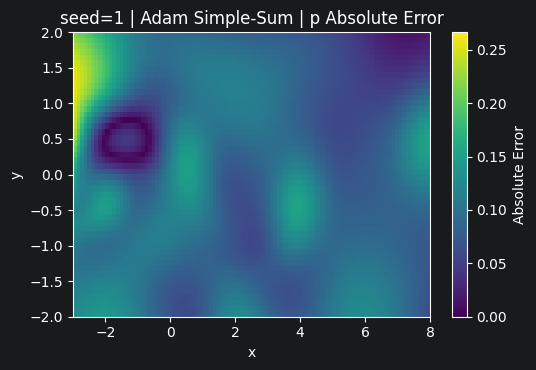

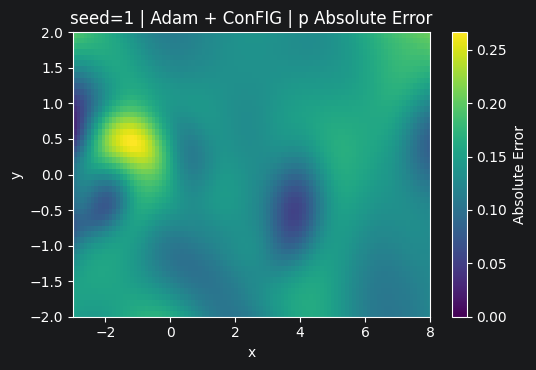

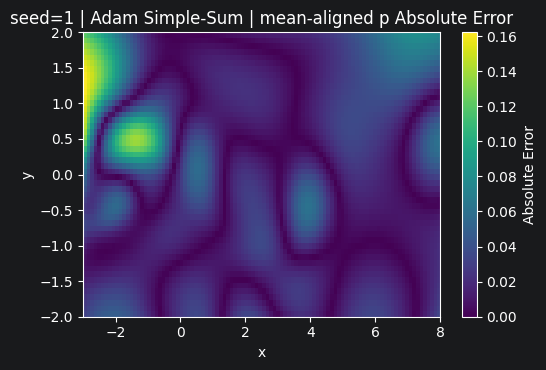

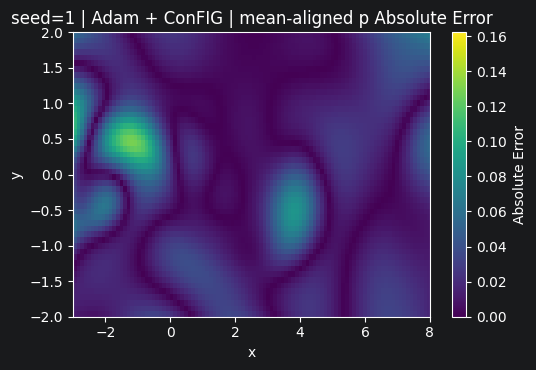


SEED 2
batch x shape: (800, 5, 1)

[Adam Simple-Sum] seed=2
params: 454106


Adam seed=2: 100%|██████████| 1000/1000 [11:19<00:00,  1.47it/s]


wall time: 679.75s (11.33min)
peak allocated: 8535.08 MiB
sampled diagnostic conflict: {'n': 101, 'mean_cosine': -0.6750307896792298, 'min_cosine': -0.9930895566940308, 'max_cosine': 0.8456167578697205, 'conflict_rate': 0.8415841584158416}

[Adam + ConFIG] seed=2
params: 454106


ConFIG seed=2: 100%|██████████| 1000/1000 [11:21<00:00,  1.47it/s]


wall time: 681.95s (11.37min)
peak allocated: 7657.07 MiB
full conflict: {'n': 1000, 'mean_cosine': -0.3392956251651485, 'min_cosine': -0.991187572479248, 'max_cosine': 0.8540710210800171, 'conflict_rate': 0.672}

Field metrics:
seed | method          | field | relative_l2 | mae       | max_absolute_error | mean_aligned_relative_l2
-----+-----------------+-------+-------------+-----------+--------------------+-------------------------
2    | Adam Simple-Sum | u     | 0.0344282   | 0.0219941 | 0.221646           |                         
2    | Adam Simple-Sum | v     | 0.124561    | 0.0245117 | 0.149124           |                         
2    | Adam Simple-Sum | p     | 18.0378     | 2.39643   | 2.56762            | 0.212959                
2    | Adam + ConFIG   | u     | 0.032932    | 0.0217603 | 0.237493           |                         
2    | Adam + ConFIG   | v     | 0.126252    | 0.0242232 | 0.193509           |                         
2    | Adam + ConFIG   | p     | 10.

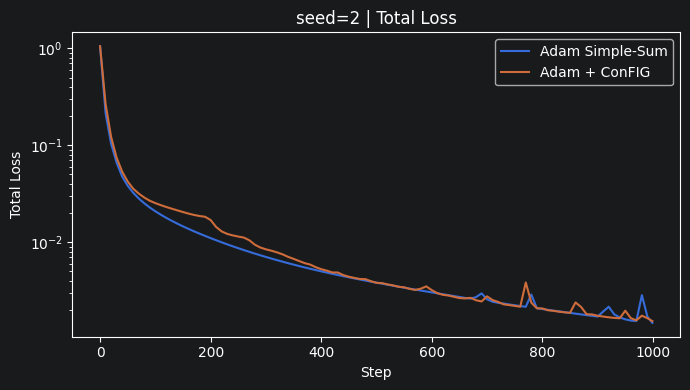

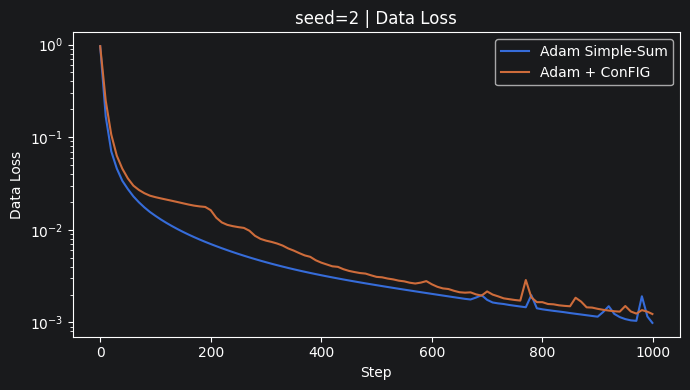

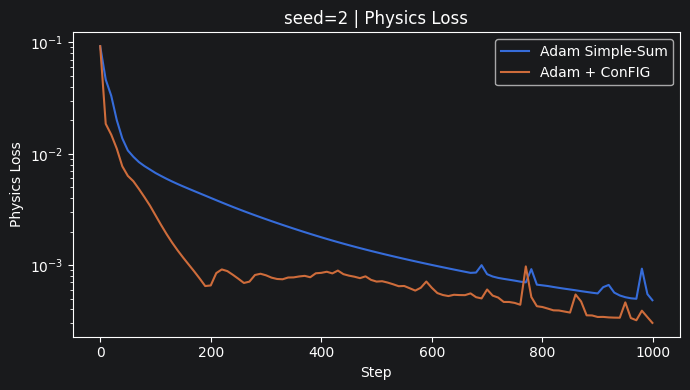

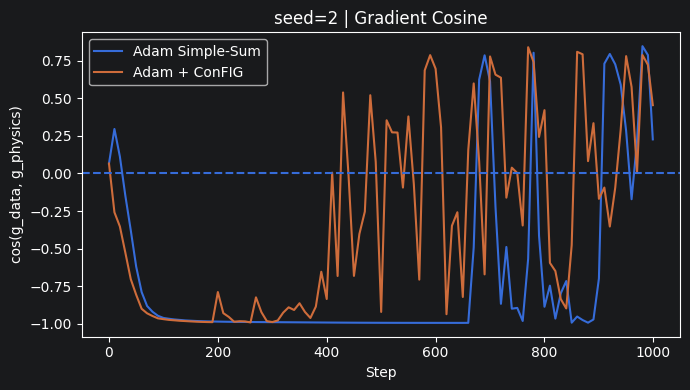

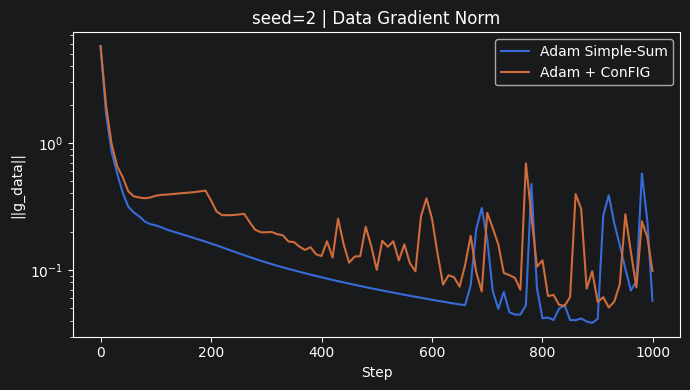

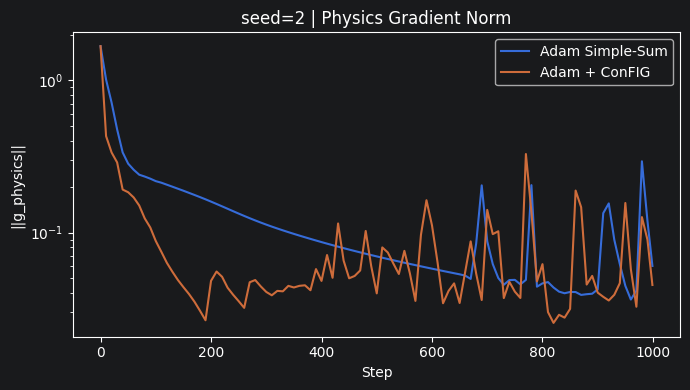

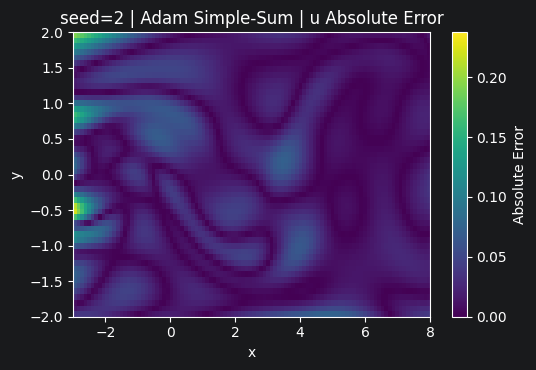

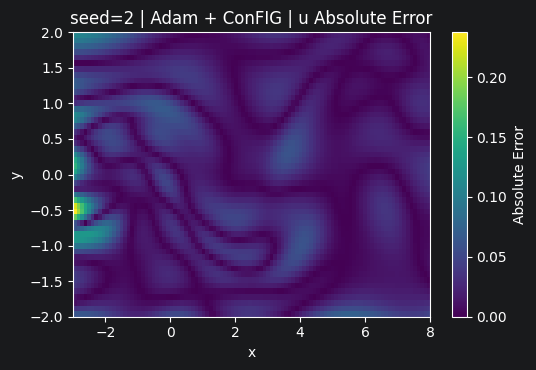

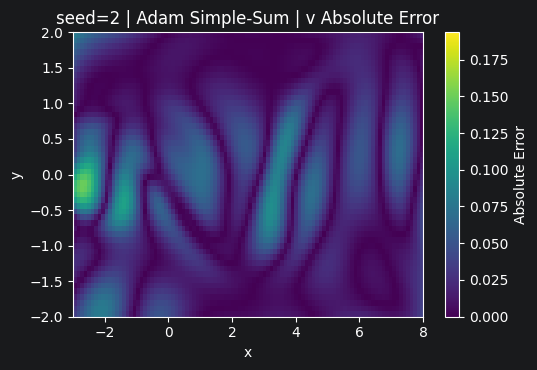

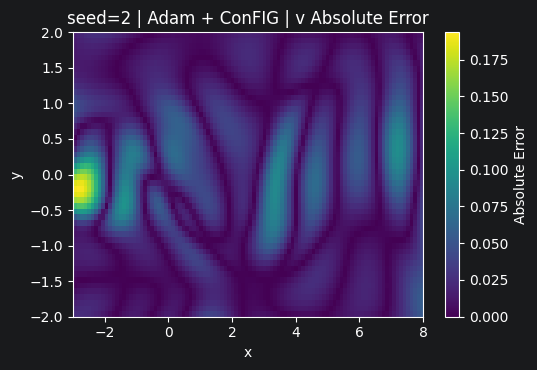

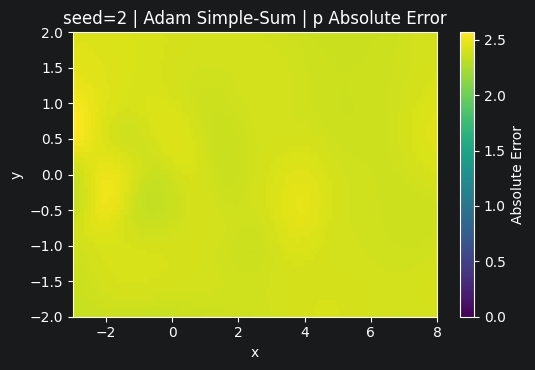

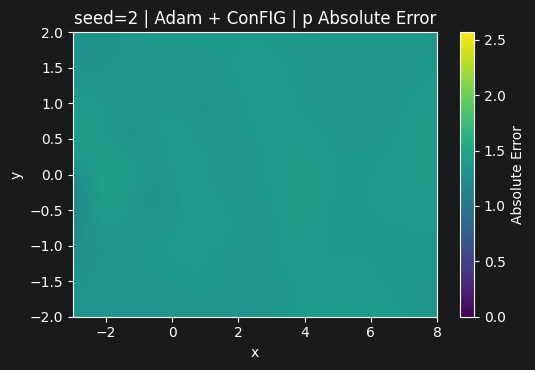

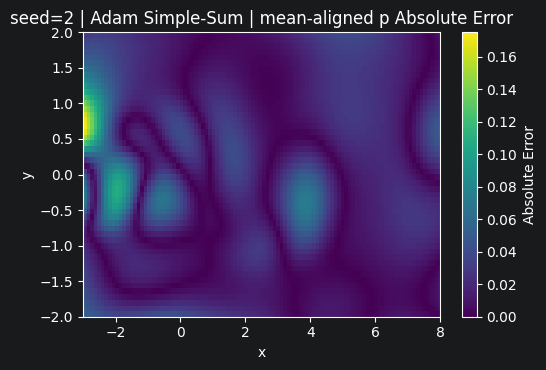

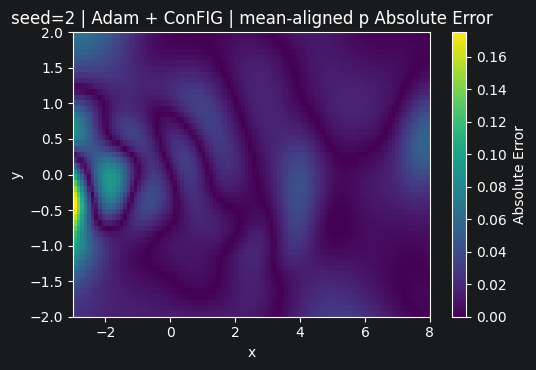


Requested new seeds finished.


In [9]:

if not torch.cuda.is_available():
    raise RuntimeError(
        "This experiment was designed to match the existing CUDA runs. "
        "Please use the configured CUDA environment."
    )

device = torch.device(DEVICE)

for seed in RUN_SEEDS:
    print("\n" + "=" * 88)
    print(f"SEED {seed}")
    print("=" * 88)

    seed_root = ensure_dir(MULTISEED_ROOT / f"seed_{seed}")
    adam_dir = ensure_dir(seed_root / "adam_simple_sum")
    config_dir = ensure_dir(seed_root / "adam_config")
    figure_dir = ensure_dir(seed_root / "figures")

    # 同一个 seed 的数据只构造一次，两种方法共享同一 batch/reference。
    set_seed(seed)
    batch, reference = load_training_data(
        DATA_PATH,
        device,
        seed=seed,
        n_train=N_TRAIN,
        num_step=NUM_STEP,
        time_step=TIME_STEP,
    )

    print("batch x shape:", tuple(batch["x"].shape))

    adam_complete = all(
        (adam_dir / name).exists()
        for name in ["model.pt", "history.npz", "run_meta.json"]
    )
    config_complete = all(
        (config_dir / name).exists()
        for name in ["model.pt", "history.npz", "run_meta.json"]
    )

    # ---------- Adam ----------
    if adam_complete and not FORCE_RERUN:
        print(f"[seed={seed}] reuse existing Adam results")
        adam_h = load_history(adam_dir / "history.npz")
        with (adam_dir / "run_meta.json").open("r", encoding="utf-8") as f:
            adam_meta = json.load(f)

        set_seed(seed)
        adam_model = make_model(device)
        adam_model.load_state_dict(
            torch.load(adam_dir / "model.pt", map_location=device)
        )
        adam_model.eval()
    else:
        adam_model, adam_history_list, adam_meta = train_adam_simple_sum(
            seed,
            batch,
            reference,
            device,
            adam_dir,
        )
        adam_h = {
            k: np.asarray([row[k] for row in adam_history_list])
            for k in adam_history_list[0]
        }

    # Adam evaluation
    ev, truth = evaluation_truth(reference, device)
    adam_pred = predict_fields(adam_model, ev)
    adam_field_rows = field_metrics(
        seed,
        "Adam Simple-Sum",
        truth,
        adam_pred,
    )
    write_dict_rows_csv(
        adam_dir / "metrics.csv",
        adam_field_rows,
    )
    save_predictions(
        adam_dir / "predictions.npz",
        truth,
        adam_pred,
    )

    del adam_model, ev
    gc.collect()
    torch.cuda.empty_cache()

    # ---------- ConFIG ----------
    if config_complete and not FORCE_RERUN:
        print(f"[seed={seed}] reuse existing ConFIG results")
        config_h = load_history(config_dir / "history.npz")
        with (config_dir / "run_meta.json").open("r", encoding="utf-8") as f:
            config_meta = json.load(f)

        set_seed(seed)
        config_model = make_model(device)
        config_model.load_state_dict(
            torch.load(config_dir / "model.pt", map_location=device)
        )
        config_model.eval()
    else:
        config_model, config_history_list, config_meta = train_adam_config(
            seed,
            batch,
            reference,
            device,
            config_dir,
        )
        config_h = {
            k: np.asarray([row[k] for row in config_history_list])
            for k in config_history_list[0]
        }

    # ConFIG evaluation
    ev2, truth2 = evaluation_truth(reference, device)
    config_pred = predict_fields(config_model, ev2)
    config_field_rows = field_metrics(
        seed,
        "Adam + ConFIG",
        truth2,
        config_pred,
    )
    write_dict_rows_csv(
        config_dir / "metrics.csv",
        config_field_rows,
    )
    save_predictions(
        config_dir / "predictions.npz",
        truth2,
        config_pred,
    )

    # ---------- 当前 seed 的数值输出 ----------
    print("\nField metrics:")
    print_table(
        adam_field_rows + config_field_rows,
        columns=[
            "seed",
            "method",
            "field",
            "relative_l2",
            "mae",
            "max_absolute_error",
            "mean_aligned_relative_l2",
        ],
    )

    seed_history_rows = [
        summarize_history(
            seed,
            "Adam Simple-Sum",
            adam_h,
            adam_meta,
        ),
        summarize_history(
            seed,
            "Adam + ConFIG",
            config_h,
            config_meta,
        ),
    ]

    print("\nHistory / resource summary:")
    print_table(
        seed_history_rows,
        columns=[
            "seed",
            "method",
            "final_data_loss",
            "final_physics_loss",
            "mean_physics_loss",
            "mean_cosine",
            "sampled_conflict_rate",
            "late_mean_cosine",
            "late_conflict_rate",
            "wall_time_min",
            "peak_vram_mib",
        ],
    )

    seed_threshold_rows = (
        threshold_rows(seed, "Adam Simple-Sum", adam_h)
        + threshold_rows(seed, "Adam + ConFIG", config_h)
    )

    print("\nPhysics threshold crossing:")
    print_table(
        seed_threshold_rows,
        columns=[
            "seed",
            "method",
            "threshold",
            "first_sampled_step_below",
        ],
    )

    write_dict_rows_csv(
        seed_root / "history_summary.csv",
        seed_history_rows,
    )
    write_dict_rows_csv(
        seed_root / "threshold_steps.csv",
        seed_threshold_rows,
    )

    # ---------- 画图 ----------
    plot_seed_training_curves(
        seed,
        adam_h,
        config_h,
        figure_dir,
    )

    plot_absolute_errors(
        seed,
        truth,
        {
            "Adam Simple-Sum": adam_pred,
            "Adam + ConFIG": config_pred,
        },
        figure_dir,
    )

    del config_model, ev2
    gc.collect()
    torch.cuda.empty_cache()

print("\nRequested new seeds finished.")



## 9. 自动纳入已有 seed=0

下面不重训 seed=0。

如果以下旧文件存在，会直接纳入三 seed 汇总：

```text
outputs/navier_stokes_adam_baseline/
    ns_pinnsformer_adam_sum.pt
    ns_pinnsformer_adam_sum_history.npz

outputs/navier_stokes_config/
    ns_pinnsformer_config_2loss.pt
    ns_pinnsformer_config_2loss_history.npz
```

seed=0 的 wall time / peak VRAM 来自已经完成的单 seed notebook：
- Adam: `642.24 s`, `8535.08 MiB`
- ConFIG: `674.29 s`, `7671.19 MiB`


In [10]:

LEGACY_SEED0 = {
    "Adam Simple-Sum": {
        "model": EXPERIMENT_ROOT
        / "outputs"
        / "navier_stokes_adam_baseline"
        / "ns_pinnsformer_adam_sum.pt",
        "history": EXPERIMENT_ROOT
        / "outputs"
        / "navier_stokes_adam_baseline"
        / "ns_pinnsformer_adam_sum_history.npz",
        "wall_time_s": 642.24,
        "peak_vram_mib": 8535.08,
    },
    "Adam + ConFIG": {
        "model": EXPERIMENT_ROOT
        / "outputs"
        / "navier_stokes_config"
        / "ns_pinnsformer_config_2loss.pt",
        "history": EXPERIMENT_ROOT
        / "outputs"
        / "navier_stokes_config"
        / "ns_pinnsformer_config_2loss_history.npz",
        "wall_time_s": 674.29,
        "peak_vram_mib": 7671.19,
    },
}

seed0_available = all(
    info["model"].exists() and info["history"].exists()
    for info in LEGACY_SEED0.values()
)

print("seed=0 legacy results available:", seed0_available)
for method, info in LEGACY_SEED0.items():
    print(method)
    print("  model  :", info["model"])
    print("  history:", info["history"])


seed=0 legacy results available: True
Adam Simple-Sum
  model  : /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_adam_baseline/ns_pinnsformer_adam_sum.pt
  history: /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_adam_baseline/ns_pinnsformer_adam_sum_history.npz
Adam + ConFIG
  model  : /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_config/ns_pinnsformer_config_2loss.pt
  history: /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_config/ns_pinnsformer_config_2loss_history.npz


## 10. 汇总 seed=0,1,2：重新统一评估 checkpoint

/tmp/ipykernel_111471/2191368686.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=device))


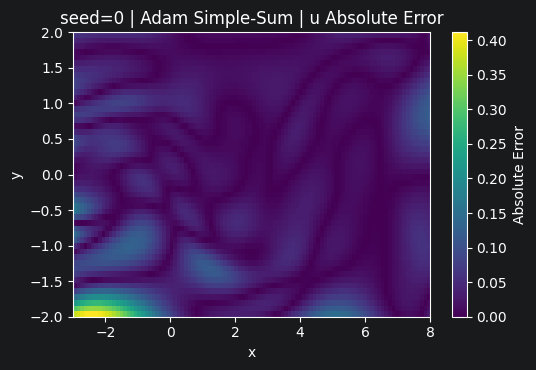

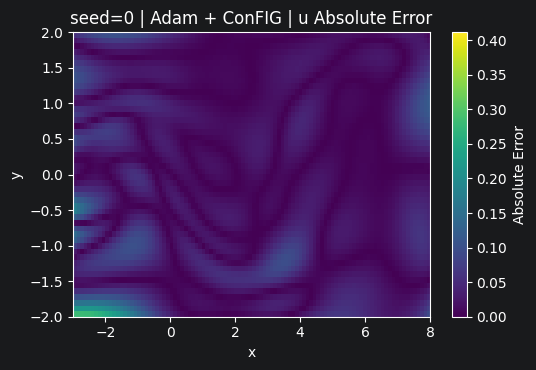

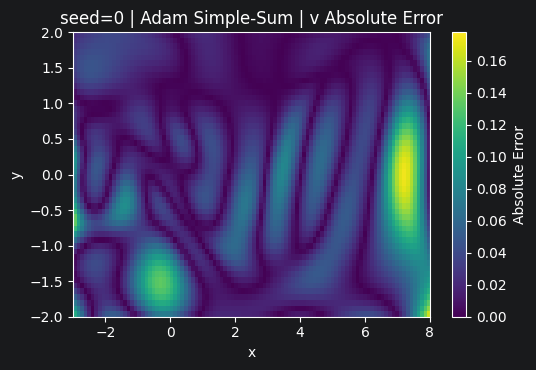

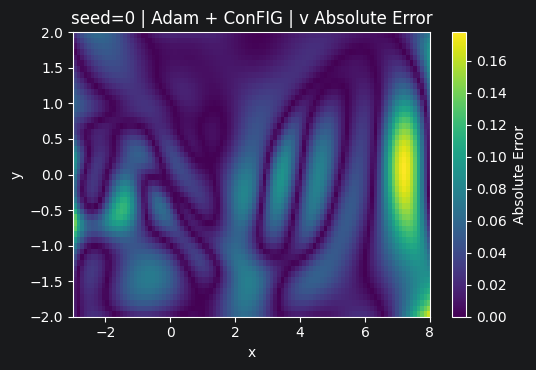

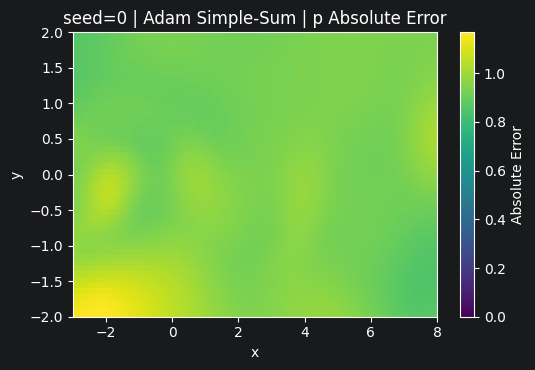

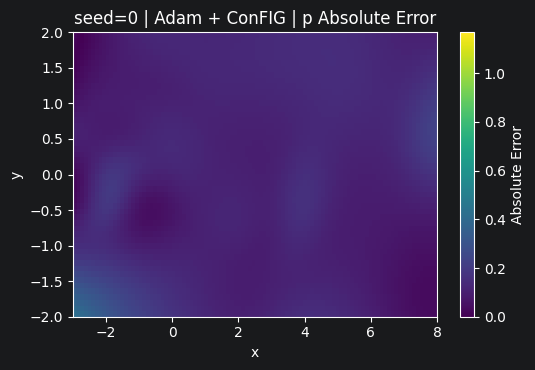

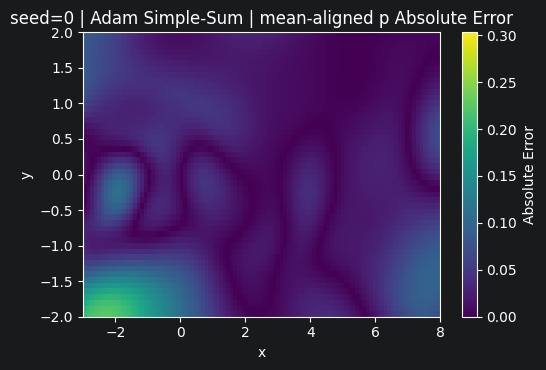

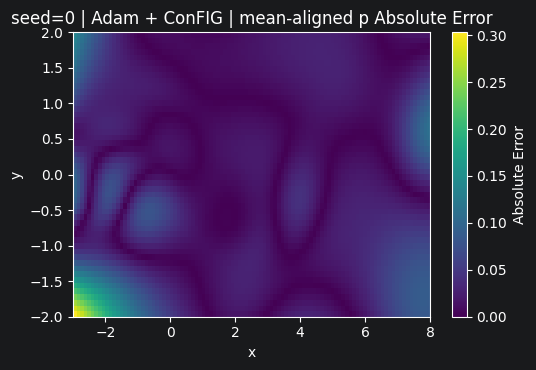

available seeds: [0, 1, 2]


In [11]:

def load_model_checkpoint(path, seed, device):
    # set_seed 只是保证构造结构时可复现；随后会覆盖为 checkpoint 权重。
    set_seed(seed)
    model = make_model(device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    return model


all_field_rows = []
all_history_rows = []
all_threshold_rows = []

available_seeds = []

# ---------- seed=0 ----------
if seed0_available:
    seed = 0
    available_seeds.append(seed)

    set_seed(seed)
    _, reference0 = load_training_data(
        DATA_PATH,
        device,
        seed=seed,
        n_train=N_TRAIN,
        num_step=NUM_STEP,
        time_step=TIME_STEP,
    )

    ev0, truth0 = evaluation_truth(reference0, device)

    seed0_preds = {}

    for method in ["Adam Simple-Sum", "Adam + ConFIG"]:
        info = LEGACY_SEED0[method]
        model = load_model_checkpoint(
            info["model"],
            seed,
            device,
        )
        pred = predict_fields(model, ev0)
        seed0_preds[method] = pred

        all_field_rows.extend(
            field_metrics(
                seed,
                method,
                truth0,
                pred,
            )
        )

        h = load_history(info["history"])
        meta = {
            "wall_time_s": info["wall_time_s"],
            "peak_vram_mib": info["peak_vram_mib"],
        }

        all_history_rows.append(
            summarize_history(
                seed,
                method,
                h,
                meta,
            )
        )
        all_threshold_rows.extend(
            threshold_rows(
                seed,
                method,
                h,
            )
        )

        del model
        gc.collect()
        torch.cuda.empty_cache()

    seed0_figure_dir = ensure_dir(
        MULTISEED_ROOT / "seed_0_recomputed_figures"
    )
    plot_absolute_errors(
        0,
        truth0,
        seed0_preds,
        seed0_figure_dir,
    )
else:
    print(
        "WARNING: seed=0 legacy outputs were not found; "
        "aggregate will use only completed multiseed directories."
    )

# ---------- seed=1,2（或任何已经完成的 RUN_SEEDS） ----------
for seed in RUN_SEEDS:
    seed_root = MULTISEED_ROOT / f"seed_{seed}"
    adam_dir = seed_root / "adam_simple_sum"
    config_dir = seed_root / "adam_config"

    complete = all(
        p.exists()
        for p in [
            adam_dir / "history.npz",
            adam_dir / "metrics.csv",
            adam_dir / "run_meta.json",
            config_dir / "history.npz",
            config_dir / "metrics.csv",
            config_dir / "run_meta.json",
        ]
    )

    if not complete:
        print(f"skip incomplete seed={seed}")
        continue

    available_seeds.append(seed)

    for method, method_dir in [
        ("Adam Simple-Sum", adam_dir),
        ("Adam + ConFIG", config_dir),
    ]:
        metric_rows = read_dict_rows_csv(method_dir / "metrics.csv")
        for row in metric_rows:
            row["seed"] = int(row["seed"])
            for key in [
                "relative_l2",
                "mae",
                "max_absolute_error",
            ]:
                row[key] = float(row[key])
            if row["mean_aligned_relative_l2"] != "":
                row["mean_aligned_relative_l2"] = float(
                    row["mean_aligned_relative_l2"]
                )
            all_field_rows.append(row)

        h = load_history(method_dir / "history.npz")
        with (method_dir / "run_meta.json").open(
            "r",
            encoding="utf-8",
        ) as f:
            meta = json.load(f)

        all_history_rows.append(
            summarize_history(
                seed,
                method,
                h,
                meta,
            )
        )
        all_threshold_rows.extend(
            threshold_rows(
                seed,
                method,
                h,
            )
        )

available_seeds = sorted(set(available_seeds))

print("available seeds:", available_seeds)


## 11. 多 Seed 原始结果表

In [12]:

AGG_DIR = ensure_dir(MULTISEED_ROOT / "aggregate")

write_dict_rows_csv(
    AGG_DIR / "all_field_metrics.csv",
    all_field_rows,
)
write_dict_rows_csv(
    AGG_DIR / "all_history_metrics.csv",
    all_history_rows,
)
write_dict_rows_csv(
    AGG_DIR / "all_threshold_steps.csv",
    all_threshold_rows,
)

print("\nAll field metrics:")
print_table(
    all_field_rows,
    columns=[
        "seed",
        "method",
        "field",
        "relative_l2",
        "mae",
        "max_absolute_error",
        "mean_aligned_relative_l2",
    ],
)

print("\nAll history metrics:")
print_table(
    all_history_rows,
    columns=[
        "seed",
        "method",
        "final_physics_loss",
        "mean_physics_loss",
        "mean_cosine",
        "sampled_conflict_rate",
        "late_mean_cosine",
        "late_conflict_rate",
        "wall_time_min",
        "peak_vram_mib",
    ],
)



All field metrics:
seed | method          | field | relative_l2 | mae       | max_absolute_error | mean_aligned_relative_l2
-----+-----------------+-------+-------------+-----------+--------------------+-------------------------
0    | Adam Simple-Sum | u     | 0.0572178   | 0.0311711 | 0.411395           |                         
0    | Adam Simple-Sum | v     | 0.162706    | 0.0315793 | 0.174138           |                         
0    | Adam Simple-Sum | p     | 7.11559     | 0.94424   | 1.16836            | 0.354244                
0    | Adam + ConFIG   | u     | 0.0438782   | 0.0265591 | 0.281162           |                         
0    | Adam + ConFIG   | v     | 0.167616    | 0.0334757 | 0.177705           |                         
0    | Adam + ConFIG   | p     | 0.963713    | 0.120951  | 0.423981           | 0.316694                
1    | Adam Simple-Sum | u     | 0.0389652   | 0.0256692 | 0.223235           |                         
1    | Adam Simple-Sum | v     | 0.

## 12. mean ± std 汇总与 paired improvement

In [13]:

def metric_values_field(method, field, key):
    values = []
    for row in all_field_rows:
        if row["method"] == method and row["field"] == field:
            value = row.get(key, "")
            if value == "" or value is None:
                continue
            values.append(float(value))
    return values


def metric_values_history(method, key):
    return [
        float(row[key])
        for row in all_history_rows
        if row["method"] == method
        and np.isfinite(float(row[key]))
    ]


summary_rows = []

# Field metrics
field_specs = [
    ("u_relative_l2", "u", "relative_l2"),
    ("v_relative_l2", "v", "relative_l2"),
    ("p_raw_relative_l2", "p", "relative_l2"),
    (
        "p_mean_aligned_relative_l2",
        "p",
        "mean_aligned_relative_l2",
    ),
]

for metric_name, field, key in field_specs:
    for method in ["Adam Simple-Sum", "Adam + ConFIG"]:
        values = metric_values_field(method, field, key)
        summary_rows.append(
            {
                "metric": metric_name,
                "method": method,
                "n": len(values),
                "mean": safe_mean(values) if values else np.nan,
                "std": safe_std(values) if values else np.nan,
            }
        )

# Training / resource metrics
for metric_name in [
    "final_physics_loss",
    "mean_physics_loss",
    "mean_cosine",
    "sampled_conflict_rate",
    "late_mean_cosine",
    "late_conflict_rate",
    "wall_time_min",
    "peak_vram_mib",
]:
    for method in ["Adam Simple-Sum", "Adam + ConFIG"]:
        values = metric_values_history(method, metric_name)
        summary_rows.append(
            {
                "metric": metric_name,
                "method": method,
                "n": len(values),
                "mean": safe_mean(values) if values else np.nan,
                "std": safe_std(values) if values else np.nan,
            }
        )

write_dict_rows_csv(
    AGG_DIR / "mean_std_summary.csv",
    summary_rows,
)

print("mean ± std summary:")
print_table(
    summary_rows,
    columns=["metric", "method", "n", "mean", "std"],
)


mean ± std summary:
metric                     | method          | n | mean        | std        
---------------------------+-----------------+---+-------------+------------
u_relative_l2              | Adam Simple-Sum | 3 | 0.0435371   | 0.0120631  
u_relative_l2              | Adam + ConFIG   | 3 | 0.0375664   | 0.00566259 
v_relative_l2              | Adam Simple-Sum | 3 | 0.140902    | 0.0196504  
v_relative_l2              | Adam + ConFIG   | 3 | 0.139822    | 0.0240724  
p_raw_relative_l2          | Adam Simple-Sum | 3 | 8.63627     | 8.74102    
p_raw_relative_l2          | Adam + ConFIG   | 3 | 4.09933     | 5.35209    
p_mean_aligned_relative_l2 | Adam Simple-Sum | 3 | 0.279382    | 0.0710192  
p_mean_aligned_relative_l2 | Adam + ConFIG   | 3 | 0.234554    | 0.0730825  
final_physics_loss         | Adam Simple-Sum | 3 | 0.000434577 | 4.31586e-05
final_physics_loss         | Adam + ConFIG   | 3 | 0.000390932 | 0.000106162
mean_physics_loss          | Adam Simple-Sum | 3 | 0.004

In [14]:

# Paired improvement：同 seed 内计算，避免被 seed 难度差异混淆。
paired_rows = []

for seed in available_seeds:
    for metric_name, field, key in field_specs:
        adam_matches = [
            row for row in all_field_rows
            if int(row["seed"]) == seed
            and row["method"] == "Adam Simple-Sum"
            and row["field"] == field
        ]
        config_matches = [
            row for row in all_field_rows
            if int(row["seed"]) == seed
            and row["method"] == "Adam + ConFIG"
            and row["field"] == field
        ]

        if not adam_matches or not config_matches:
            continue

        a = adam_matches[0].get(key, "")
        c = config_matches[0].get(key, "")
        if a == "" or c == "":
            continue

        a = float(a)
        c = float(c)

        paired_rows.append(
            {
                "seed": seed,
                "metric": metric_name,
                "adam": a,
                "config": c,
                # 对 error/loss 指标，正值表示 ConFIG 更好。
                "config_improvement_percent": (a - c) / a * 100.0,
            }
        )

write_dict_rows_csv(
    AGG_DIR / "paired_improvement.csv",
    paired_rows,
)

print("Paired field-error improvement:")
print_table(
    paired_rows,
    columns=[
        "seed",
        "metric",
        "adam",
        "config",
        "config_improvement_percent",
    ],
)


Paired field-error improvement:
seed | metric                     | adam      | config    | config_improvement_percent
-----+----------------------------+-----------+-----------+---------------------------
0    | u_relative_l2              | 0.0572178 | 0.0438782 | 23.3138                   
0    | v_relative_l2              | 0.162706  | 0.167616  | -3.01776                  
0    | p_raw_relative_l2          | 7.11559   | 0.963713  | 86.4563                   
0    | p_mean_aligned_relative_l2 | 0.354244  | 0.316694  | 10.6                      
1    | u_relative_l2              | 0.0389652 | 0.035889  | 7.89474                   
1    | v_relative_l2              | 0.135439  | 0.125598  | 7.26603                   
1    | p_raw_relative_l2          | 0.75537   | 1.05511   | -39.6811                  
1    | p_mean_aligned_relative_l2 | 0.270944  | 0.210243  | 22.4034                   
2    | u_relative_l2              | 0.0344282 | 0.032932  | 4.34596                   
2    | v_re

## 13. Physics threshold 的多 Seed 汇总

In [15]:

threshold_summary_rows = []

for threshold in PHYSICS_THRESHOLDS:
    for method in ["Adam Simple-Sum", "Adam + ConFIG"]:
        values = []
        for row in all_threshold_rows:
            if (
                row["method"] == method
                and np.isclose(float(row["threshold"]), threshold)
            ):
                v = float(row["first_sampled_step_below"])
                if np.isfinite(v):
                    values.append(v)

        threshold_summary_rows.append(
            {
                "threshold": threshold,
                "method": method,
                "n_crossed": len(values),
                "mean_first_sampled_step": (
                    safe_mean(values) if values else np.nan
                ),
                "std_first_sampled_step": (
                    safe_std(values) if values else np.nan
                ),
            }
        )

write_dict_rows_csv(
    AGG_DIR / "threshold_mean_std.csv",
    threshold_summary_rows,
)

print_table(
    threshold_summary_rows,
    columns=[
        "threshold",
        "method",
        "n_crossed",
        "mean_first_sampled_step",
        "std_first_sampled_step",
    ],
)


threshold | method          | n_crossed | mean_first_sampled_step | std_first_sampled_step
----------+-----------------+-----------+-------------------------+-----------------------
0.01      | Adam Simple-Sum | 3         | 63.3333                 | 5.7735                
0.01      | Adam + ConFIG   | 3         | 36.6667                 | 5.7735                
0.005     | Adam Simple-Sum | 3         | 163.333                 | 5.7735                
0.005     | Adam + ConFIG   | 3         | 73.3333                 | 5.7735                
0.002     | Adam Simple-Sum | 3         | 383.333                 | 23.094                
0.002     | Adam + ConFIG   | 3         | 126.667                 | 5.7735                
0.001     | Adam Simple-Sum | 3         | 606.667                 | 25.1661               
0.001     | Adam + ConFIG   | 3         | 166.667                 | 5.7735                
0.0005    | Adam Simple-Sum | 3         | 920                     | 43.589                

## 14. 多 Seed 汇总图

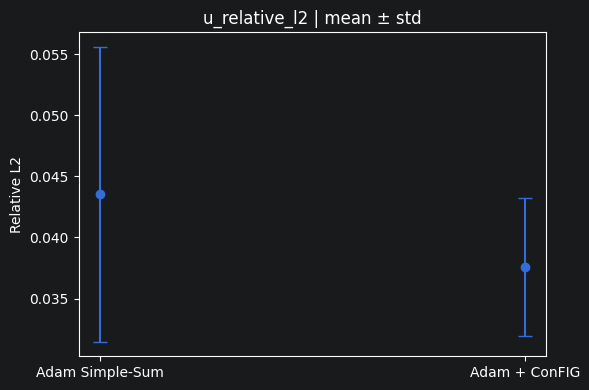

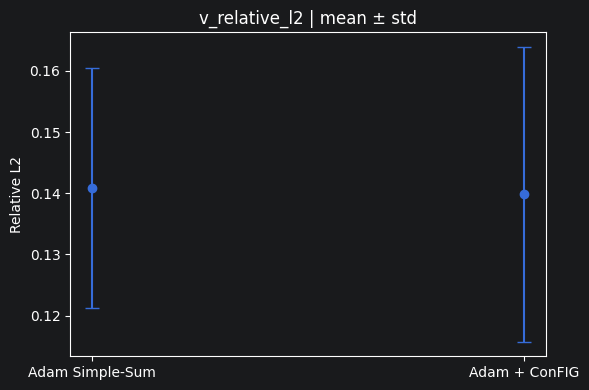

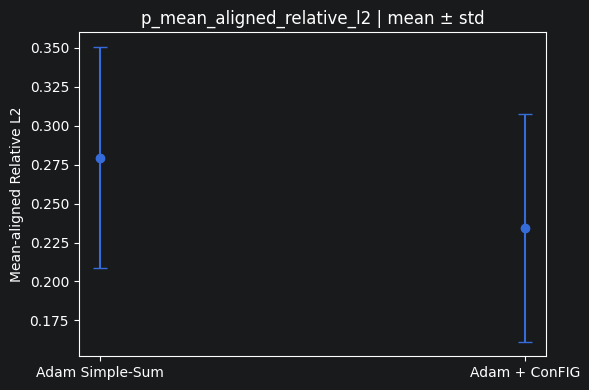

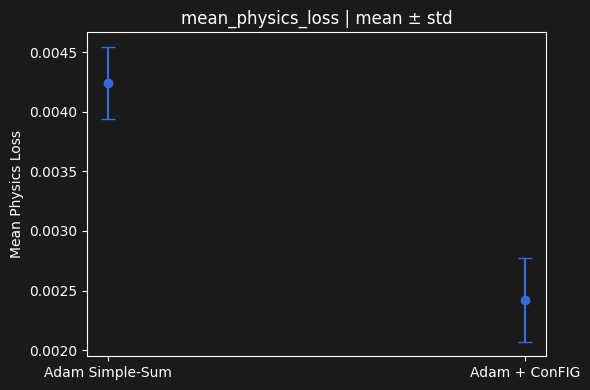

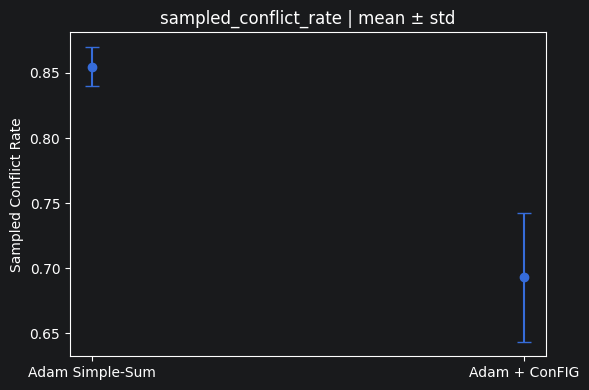

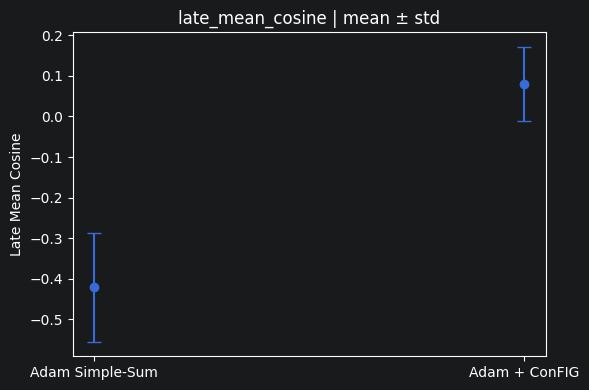

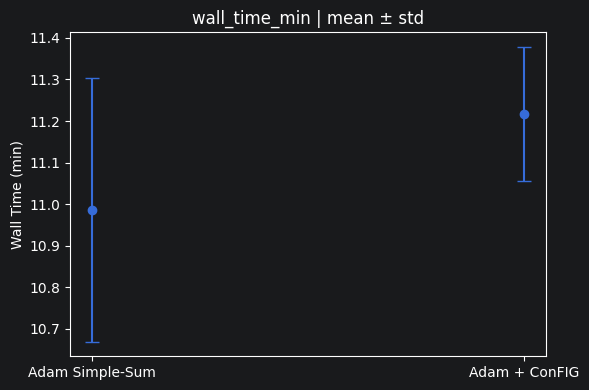

In [16]:

def find_summary(metric, method):
    matches = [
        row for row in summary_rows
        if row["metric"] == metric
        and row["method"] == method
    ]
    if not matches:
        return np.nan, np.nan
    return float(matches[0]["mean"]), float(matches[0]["std"])


def plot_two_method_errorbar(metric, ylabel, filename):
    methods = ["Adam Simple-Sum", "Adam + ConFIG"]
    means = []
    stds = []

    for method in methods:
        mean, std = find_summary(metric, method)
        means.append(mean)
        stds.append(0.0 if not np.isfinite(std) else std)

    x = np.arange(len(methods))

    plt.figure(figsize=(6, 4))
    plt.errorbar(
        x,
        means,
        yerr=stds,
        fmt="o",
        capsize=5,
    )
    plt.xticks(x, methods)
    plt.ylabel(ylabel)
    plt.title(f"{metric} | mean ± std")
    plt.tight_layout()
    plt.savefig(
        AGG_DIR / filename,
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()


plot_two_method_errorbar(
    "u_relative_l2",
    "Relative L2",
    "aggregate_u_relative_l2.png",
)

plot_two_method_errorbar(
    "v_relative_l2",
    "Relative L2",
    "aggregate_v_relative_l2.png",
)

plot_two_method_errorbar(
    "p_mean_aligned_relative_l2",
    "Mean-aligned Relative L2",
    "aggregate_p_mean_aligned_relative_l2.png",
)

plot_two_method_errorbar(
    "mean_physics_loss",
    "Mean Physics Loss",
    "aggregate_mean_physics_loss.png",
)

plot_two_method_errorbar(
    "sampled_conflict_rate",
    "Sampled Conflict Rate",
    "aggregate_conflict_rate.png",
)

plot_two_method_errorbar(
    "late_mean_cosine",
    "Late Mean Cosine",
    "aggregate_late_mean_cosine.png",
)

plot_two_method_errorbar(
    "wall_time_min",
    "Wall Time (min)",
    "aggregate_wall_time.png",
)


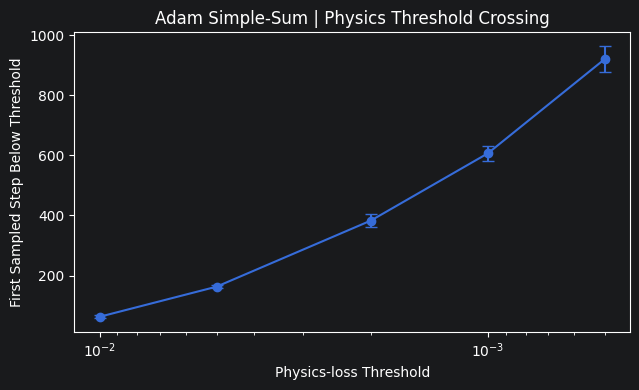

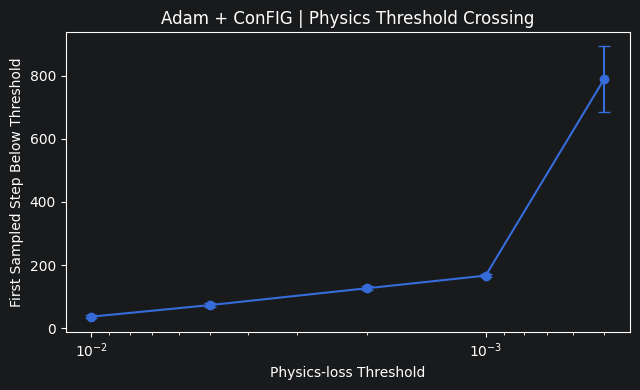

In [17]:

# 多 seed threshold crossing 曲线
for method in ["Adam Simple-Sum", "Adam + ConFIG"]:
    xs = []
    ys = []
    yerrs = []

    for threshold in PHYSICS_THRESHOLDS:
        matches = [
            row for row in threshold_summary_rows
            if row["method"] == method
            and np.isclose(float(row["threshold"]), threshold)
        ]
        if not matches:
            continue

        mean_step = float(matches[0]["mean_first_sampled_step"])
        std_step = float(matches[0]["std_first_sampled_step"])

        if np.isfinite(mean_step):
            xs.append(threshold)
            ys.append(mean_step)
            yerrs.append(
                0.0 if not np.isfinite(std_step) else std_step
            )

    plt.figure(figsize=(6.5, 4))
    plt.errorbar(
        xs,
        ys,
        yerr=yerrs,
        fmt="o-",
        capsize=4,
    )
    plt.xscale("log")
    plt.gca().invert_xaxis()
    plt.xlabel("Physics-loss Threshold")
    plt.ylabel("First Sampled Step Below Threshold")
    plt.title(f"{method} | Physics Threshold Crossing")
    plt.tight_layout()

    safe_method = (
        method.lower()
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("-", "_")
    )
    plt.savefig(
        AGG_DIR / f"aggregate_{safe_method}_threshold_crossing.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()



## 15. 如何判断多 Seed 结果是否支持继续研究

不要要求每个 seed、每个物理变量都“全部胜出”。重点看以下证据是否具有重复性：

- `u Relative L2`：ConFIG 是否多数 seed 都更低？
- `v Relative L2`：seed=0 的轻微退化是否重复，还是只是随机波动？
- `p mean-aligned Relative L2`：去掉 pressure gauge 后是否仍多数 seed 改善？
- `Mean / Final Physics Loss`：ConFIG 是否稳定更低？
- `Physics threshold crossing`：ConFIG 是否多数 seed 更早达到相同 physics-loss target？
- `Sampled conflict rate / late cosine`：ConFIG 后期是否重复进入 conflict 更弱的区域？
- `Wall time`：标准 ConFIG 的额外代价是否稳定、量级是多少？
- `Peak VRAM`：只记录，不因为 3 次测量就宣称算法必然降显存。

如果 `seed=0,1,2` 的主要现象方向一致，再进入 M-ConFIG：

```text
Adam Simple-Sum
       vs
Adam + ConFIG
       ↓
确认精度 / physics / conflict 的多 seed 稳定性
       ↓
固定同一 benchmark
加入原始 M-ConFIG
       ↓
重点比较 accuracy / wall time / backward count / gradient staleness
       ↓
有证据后才研究 dynamic M-ConFIG
```


## 16. 输出文件清单

In [18]:

print("All outputs root:")
print(MULTISEED_ROOT.resolve())

print("\nExpected structure:")
print(
    """
navier_stokes_multiseed/
├── seed_1/
│   ├── adam_simple_sum/
│   │   ├── model.pt
│   │   ├── history.npz
│   │   ├── predictions.npz
│   │   ├── metrics.csv
│   │   └── run_meta.json
│   ├── adam_config/
│   │   └── ...
│   ├── history_summary.csv
│   ├── threshold_steps.csv
│   └── figures/
├── seed_2/
│   └── ...
├── seed_0_recomputed_figures/
└── aggregate/
    ├── all_field_metrics.csv
    ├── all_history_metrics.csv
    ├── all_threshold_steps.csv
    ├── mean_std_summary.csv
    ├── paired_improvement.csv
    ├── threshold_mean_std.csv
    └── *.png
"""
)


All outputs root:
/home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_multiseed

Expected structure:

navier_stokes_multiseed/
├── seed_1/
│   ├── adam_simple_sum/
│   │   ├── model.pt
│   │   ├── history.npz
│   │   ├── predictions.npz
│   │   ├── metrics.csv
│   │   └── run_meta.json
│   ├── adam_config/
│   │   └── ...
│   ├── history_summary.csv
│   ├── threshold_steps.csv
│   └── figures/
├── seed_2/
│   └── ...
├── seed_0_recomputed_figures/
└── aggregate/
    ├── all_field_metrics.csv
    ├── all_history_metrics.csv
    ├── all_threshold_steps.csv
    ├── mean_std_summary.csv
    ├── paired_improvement.csv
    ├── threshold_mean_std.csv
    └── *.png

